# 변수중요도 : Feature Importance



## 1.환경준비

### 1) 라이브러리 로딩

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore')

### 2) 데이터 로딩

In [57]:
data = pd.read_csv('https://raw.githubusercontent.com/DA4BAM/dataset/master/boston.csv')
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


* 변수 설명
    * crim : 범죄율
    * zn : 대저택 비율
    * indus : 산업단지 비율
    * chas : 찰스 강변 여부
    * nox : 일산화질소 농도(공기오염도)
    * rm : 평균 주택당 방 수
    * age : 30년 이상된 주택 비율
    * dis : 주요 업무 지역 접근성 지수
    * rad : 고속도로 접근성 지수
    * tax  1만 달러당 재산세
    * ptratio : 교사 1명당 학생수
    * lstat : 하위계층 비율
    * black : 흑인비율(원래 숫자를 변형한 것임)
    * medv : 타운별 집값 중위수(단위 : 1000달러)

### 3) 필요한 함수 생성

In [5]:
# 변수 중요도 plot
def plot_feature_importance(importance, names, topn = 'all'):
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    data={'feature_names':feature_names,'feature_importance':feature_importance}
    fi_temp = pd.DataFrame(data)

    fi_temp.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    fi_temp.reset_index(drop=True, inplace = True)

    if topn == 'all' :
        fi_df = fi_temp.copy()
    else :
        fi_df = fi_temp.iloc[:topn]

    plt.figure(figsize=(10,8))
    sns.barplot(x='feature_importance', y='feature_names', data = fi_df)

    plt.xlabel('importance')
    plt.ylabel('feature names')
    plt.grid()

    return fi_df

## 2.데이터 준비


### 1) x, y로 나누기 

In [61]:
target = 'medv'
x = data.drop(target, axis = 1)
y = data.loc[:,target]

### 2) 가변수화

### 3) train : validation 분할

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = .2, random_state = 2022)
x_train.shape

(404, 13)

## 3.Feature Importance

### 1) Decision Tree

In [64]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import * 

* 기본 모델

In [65]:
model = DecisionTreeRegressor(max_depth = 3)
model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=3)

* 모델 시각화

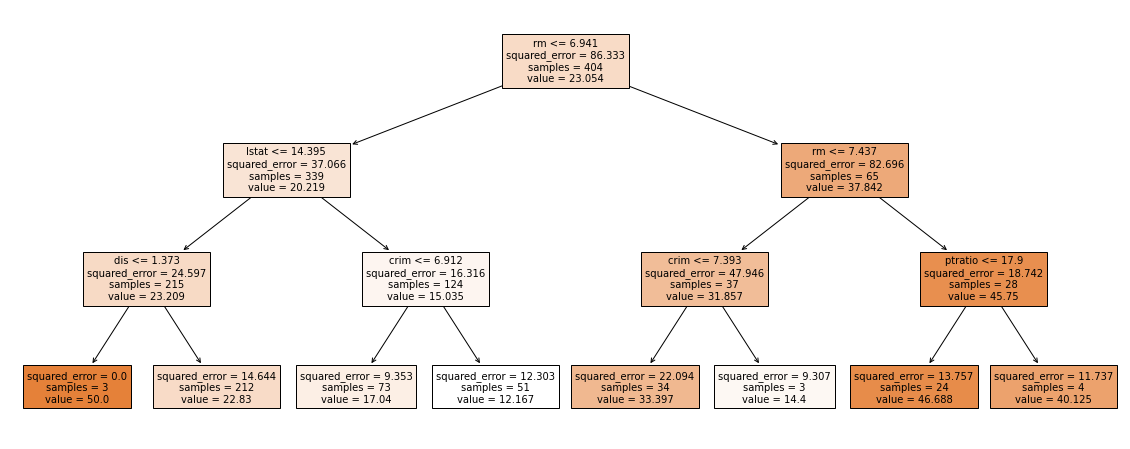

In [66]:
#회귀는 MSE
#분류는 지니 불순도
plt.figure(figsize = (20, 8))
plot_tree(model, feature_names = x.columns,
          filled = True, fontsize = 10);

* 변수 중요도

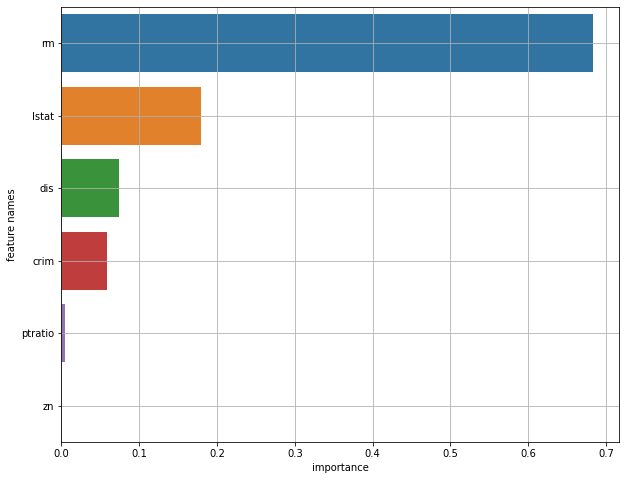

In [67]:
result = plot_feature_importance(model.feature_importances_, list(x), 6)

In [68]:
result

,feature_names,feature_importance
0,rm,0.682914
1,lstat,0.179261
2,dis,0.074513
3,crim,0.058274
4,ptratio,0.005038
5,zn,0.000000


* 성능 최적화 이후 변수 중요도 다시 확인

In [69]:
from sklearn.model_selection import GridSearchCV

params = {'max_depth':range(1, 10)}
model = DecisionTreeRegressor()
model_gs = GridSearchCV(model, params, cv = 5)
model_gs.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': range(1, 10)})

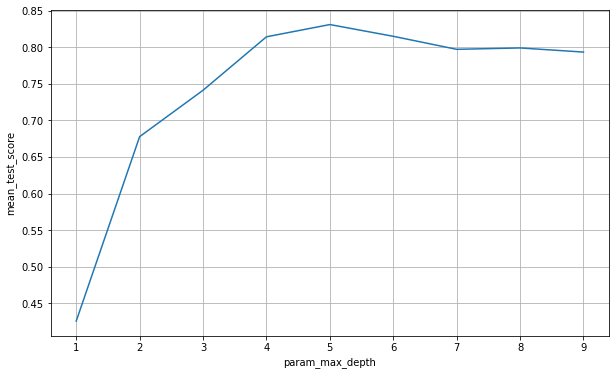

In [70]:
# 튜닝 과정 로그를 df로 저장
result = pd.DataFrame(model_gs.cv_results_)

plt.figure(figsize = (10,6))
sns.lineplot(x='param_max_depth', y='mean_test_score', data = result)
plt.grid()
plt.show()

In [71]:
best_model = model_gs.best_estimator_

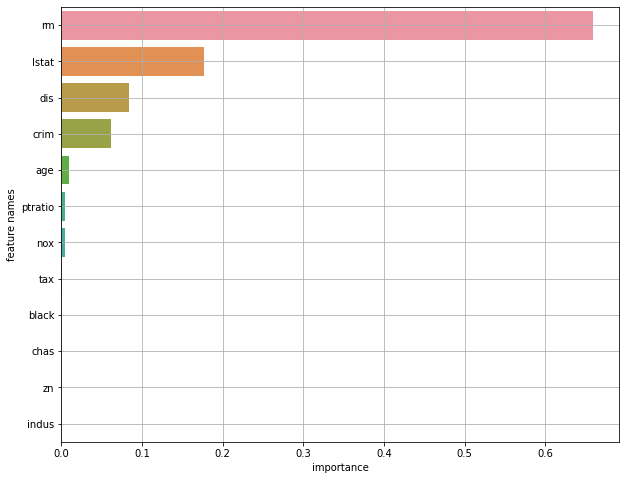

In [72]:
result = plot_feature_importance(best_model.feature_importances_, list(x),12)

In [74]:
# pred = model_gs.predict(x_val)
pred = best_model.predict(x_val)
print(mean_absolute_error(y_val, pred))
print(mean_absolute_percentage_error(y_val, pred))
print(r2_score(y_val,pred))

3.1933449978231767
0.18656720073911942
0.6903393973145242


### 2) Random Forest

* 기본모델링

In [19]:
from sklearn.ensemble import RandomForestRegressor

In [75]:
n_est = 3
model = RandomForestRegressor(n_estimators = n_est, max_depth = 2)
model.fit(x_train, y_train)

RandomForestRegressor(max_depth=2, n_estimators=3)

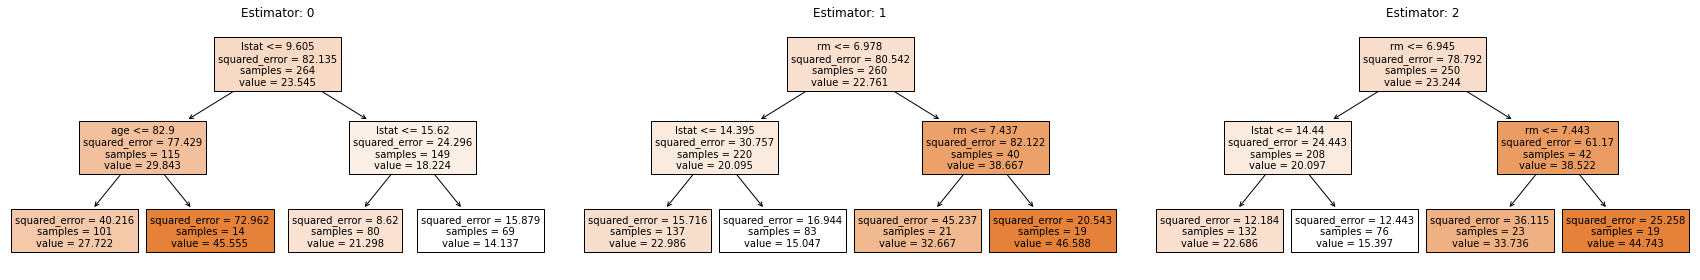

In [76]:
fn=list(x_train)
cn=["0","1"]
fig, axes = plt.subplots(nrows = 1,ncols = n_est,figsize = (24,4))
for index in range(0, n_est):
    plot_tree(model.estimators_[index],
                   feature_names = fn, 
                   class_names=cn,
                   filled = True, fontsize = 10,
                   ax = axes[index]);
    axes[index].set_title('Estimator: ' + str(index), fontsize = 12)
    
plt.tight_layout()
plt.show()

살짝살짝 기준이 다르다  
개별 트리로 설명은 그닥 불필요  

In [82]:
fi = x_train.iloc[0:0]
fi

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat


In [83]:
fi = x_train.iloc[0:0] #데이터 없음 -> 구조만 만들어줘
for i in range(n_est) :
    fi.loc[i] = model.estimators_[i].feature_importances_

In [84]:
fi

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.274538,0.0,0.0,0.0,0.0,0.0,0.725462
1,0.0,0.0,0.0,0.0,0.0,0.797533,0.000000,0.0,0.0,0.0,0.0,0.0,0.202467
2,0.0,0.0,0.0,0.0,0.0,0.840487,0.000000,0.0,0.0,0.0,0.0,0.0,0.159513


fi = 각 트리에 대한 변수 중요도 결과

In [85]:
fi.mean(axis = 0) #평균계산

crim       0.000000
zn         0.000000
indus      0.000000
chas       0.000000
nox        0.000000
rm         0.546007
age        0.091513
dis        0.000000
rad        0.000000
tax        0.000000
ptratio    0.000000
black      0.000000
lstat      0.362481
dtype: float64

In [86]:
fi_rf = {} #평균내서 데이터 프레임으로 만들기

for i, v in enumerate(list(x)) :
    fi_rf[v] = model.feature_importances_[i]

pd.DataFrame(fi_rf, index = [0])

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,0.0,0.0,0.0,0.0,0.0,0.546007,0.091513,0.0,0.0,0.0,0.0,0.0,0.362481


개별 트리의 변수 중요도 평균이 랜덤포레스트 변수 중요도와 같다  

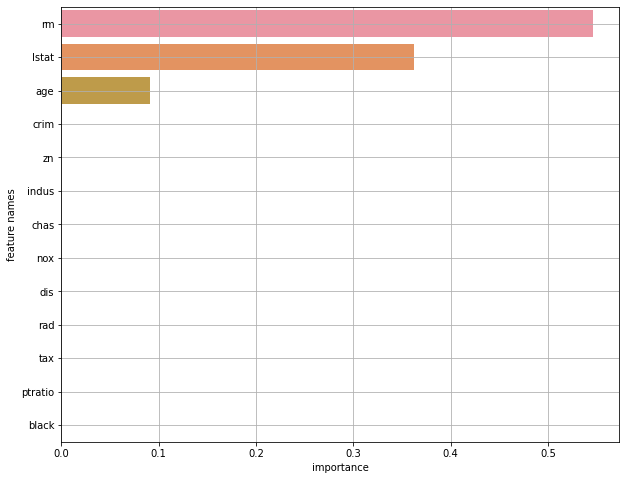

In [81]:
result = plot_feature_importance(model.feature_importances_, list(x))

* tree = 100개 Random Forest 모델 만들기

In [87]:
model = RandomForestRegressor() 
model.fit(x_train, y_train)

RandomForestRegressor()

* 트리 전체 중요도 저장

In [88]:
fi = x_train.iloc[0:0]
for i in range(100) :
    fi.loc[i] = model.estimators_[i].feature_importances_

In [89]:
fi

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,0.033074,0.000281,0.001314,0.000530,0.011855,0.145886,0.010001,0.073671,0.003763,0.002322,0.012961,0.007950,0.696392
1,0.103598,0.000107,0.001380,0.000001,0.021745,0.283913,0.004560,0.005885,0.000480,0.011587,0.005776,0.013690,0.547279
2,0.014678,0.000037,0.001059,0.000481,0.019396,0.696479,0.010872,0.053599,0.001730,0.009707,0.008895,0.004981,0.178086
3,0.009830,0.000379,0.001311,0.000003,0.036441,0.648460,0.015525,0.102320,0.000343,0.008408,0.000919,0.008990,0.167071
4,0.023145,0.000209,0.007218,0.001100,0.005546,0.545636,0.099386,0.012424,0.001740,0.003852,0.003758,0.006848,0.289140
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.037551,0.004775,0.007067,0.000020,0.007117,0.103168,0.008397,0.062103,0.000087,0.005546,0.003320,0.030274,0.730576
96,0.023167,0.000021,0.005783,0.000160,0.009272,0.588653,0.008978,0.084669,0.001335,0.022296,0.005748,0.005578,0.244340
97,0.068804,0.000316,0.003754,0.000258,0.002733,0.613514,0.021012,0.096166,0.003132,0.013447,0.011807,0.011611,0.153446
98,0.100804,0.001273,0.004936,0.000210,0.004456,0.297319,0.012535,0.025433,0.000455,0.003102,0.017027,0.008653,0.523797


* 트리 100개의 평균 중요도

In [90]:
fi.mean(axis = 0)

crim       0.034656
zn         0.000980
indus      0.004383
chas       0.001301
nox        0.017076
rm         0.500005
age        0.014640
dis        0.068131
rad        0.002922
tax        0.008658
ptratio    0.012086
black      0.009450
lstat      0.325712
dtype: float64

In [91]:
fi_rf = {}

for i, v in enumerate(list(x)) :
    fi_rf[v] = model.feature_importances_[i]

pd.DataFrame(fi_rf, index = [0])

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,0.034656,0.00098,0.004383,0.001301,0.017076,0.500005,0.01464,0.068131,0.002922,0.008658,0.012086,0.00945,0.325712


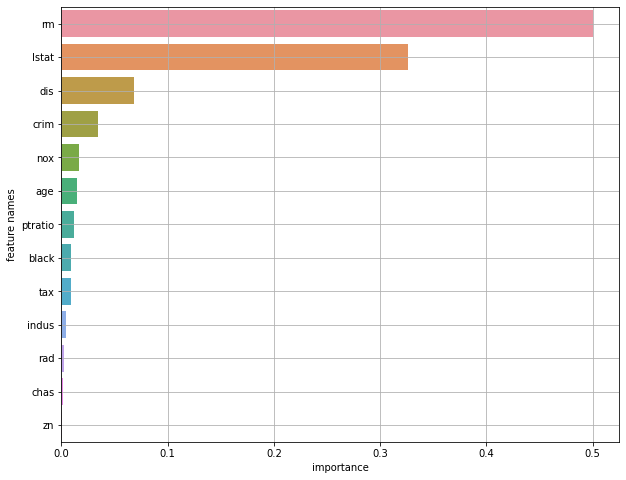

In [92]:
result = plot_feature_importance(model.feature_importances_, list(x))

In [94]:
pred = model.predict(x_val)
print(mean_absolute_error(y_val, pred))
print(mean_absolute_percentage_error(y_val, pred))
print(r2_score(y_val,pred))

2.4588333333333336
0.13148176998423802
0.7918533143153339


### 3) XGB

In [95]:
from xgboost import XGBRegressor, plot_tree, plot_importance

* 기본 모델링

In [96]:
model = XGBRegressor(n_estimators = 10, max_depth = 2, objective='reg:squarederror')
model.fit(x_train, y_train)

XGBRegressor(max_depth=2, n_estimators=10, objective='reg:squarederror')

* plot tree
    * plot tree함수는 XGB에서 제공합니다.
    * XGB에서의 트리 시각화는 여러 estimator중 하나씩만 가능합니다.

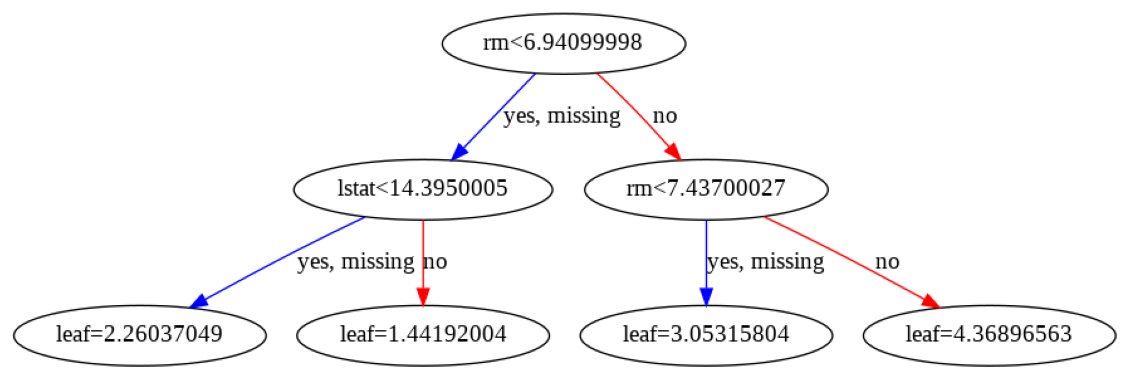

In [97]:
plt.rcParams['figure.figsize'] = 20,20
plot_tree(model)
plt.show()

* leaf 노드의 값 ==> 로지스틱 함수에 넣으면 0~1 사이의 값으로 변환됨.

* 몇가지 옵션
    * num_trees = 0
    * rankdir='LR'

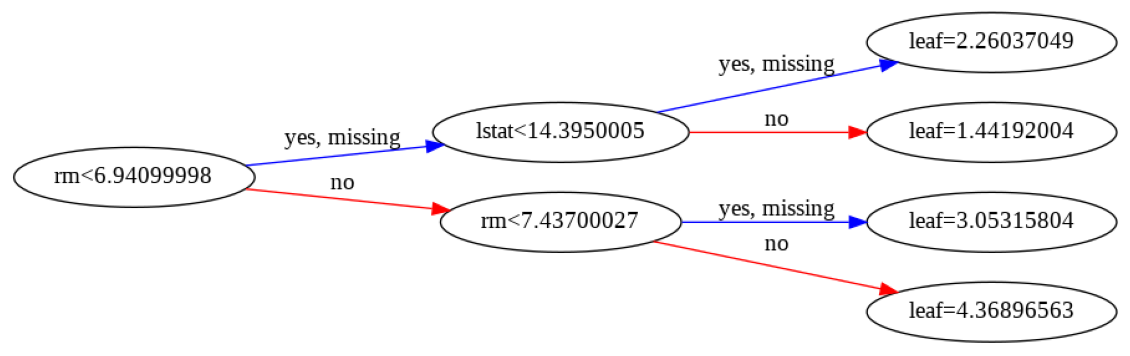

In [98]:
plot_tree(model, num_trees = 0, rankdir = 'LR')
plt.show()

* plot_importance
    * 변수중요도 기본값은 weight

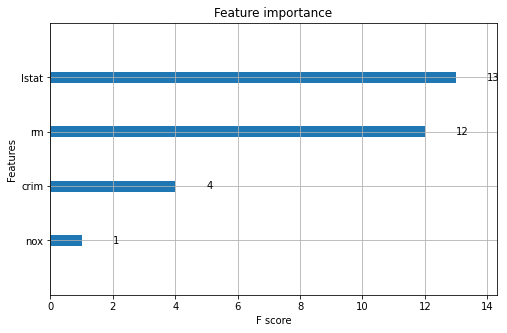

In [99]:
#weight -> split될때 사용된 횟수
plt.rcParams['figure.figsize'] = 8, 5
plot_importance(model)
plt.show()

* model.feature_importances_ : 변수중요도 기본값은 gain.

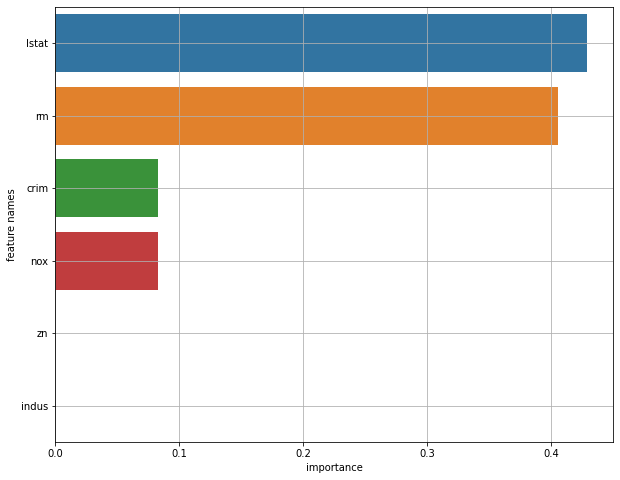

In [100]:
#decision tree와 같은 방법
result = plot_feature_importance(model.feature_importances_, list(x),6)

* xgb의 변수 중요도
    * weight : 모델 전체에서 해당 feature가 split될 때 사용된 횟수의 합(plot_tree 에서의 기본값)
    * gain : feature별 평균 imformation gain.(model.feature_importances_ 의 기본값)
    * cover : feature가 split 할때의 샘플 수의 평균.

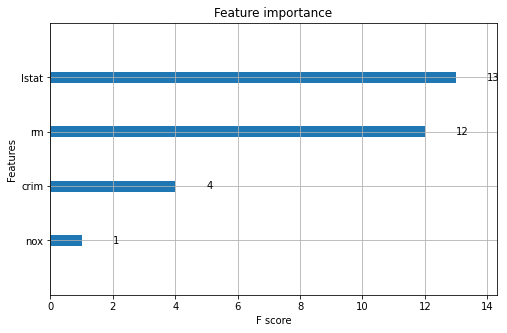

In [40]:
# importance_type='weight'
plot_importance(model)
plt.show()

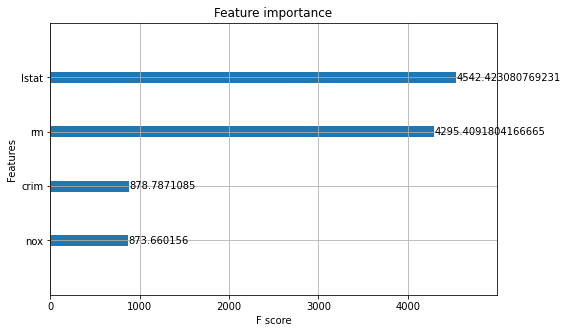

In [41]:
# importance_type='gain'
plot_importance(model, importance_type='gain')
plt.show()

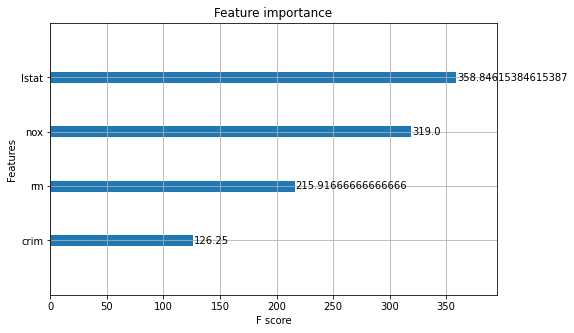

In [42]:
# importance_type='cover'
plot_importance(model, importance_type='cover')
plt.show()

## 4.실습 : 직원 이직 예측모델 변수 중요도 비교

### 4.1 데이터 준비

* 데이터 로딩

In [111]:
# data data
path = "https://raw.githubusercontent.com/DA4BAM/dataset/master/Attrition2.csv"
data = pd.read_csv(path)
data.head(10)

,Attrition,Age,Department,DistanceFromHome,Education,EducationField,Gender,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany
0,0,28,Research & Development,1,3,Medical,Female,Research Scientist,1,Married,3591,1,3,3,3,3,3
1,1,37,Research & Development,2,2,Other,Male,Laboratory Technician,3,Single,2090,6,2,7,3,3,0
2,0,27,Research & Development,8,5,Life Sciences,Male,Laboratory Technician,3,Married,4621,1,4,3,4,3,3
3,0,18,Research & Development,1,3,Life Sciences,Female,Laboratory Technician,4,Single,1611,1,3,0,5,4,0
4,0,29,Research & Development,9,3,Life Sciences,Male,Research Scientist,3,Married,2451,6,1,5,2,2,1
5,0,44,Research & Development,2,1,Medical,Male,Manufacturing Director,3,Single,10209,5,2,16,2,2,2
6,0,41,Sales,10,2,Life Sciences,Male,Sales Executive,4,Single,6230,7,4,16,3,3,14
7,0,25,Sales,18,1,Life Sciences,Male,Sales Executive,3,Married,6232,2,2,6,3,2,3
8,0,50,Research & Development,2,3,Medical,Male,Research Director,3,Married,17639,5,4,30,3,3,4
9,0,47,Sales,4,2,Life Sciences,Female,Sales Executive,4,Single,4163,1,3,9,0,3,9


|	변수 명	|	내용	|	구분	|
|	----	|	----	|	----	|
|	**Attrition**	|	이직여부, Yes = 1 , No = 0	|	**Target**	|
|	Age	|	나이	|	숫자	|
|	BusinessTravel	|	출장 빈도(범주)	|		|
|	Department	|	현 부서	|		|
|	DistanceFromHome	|	집-직장 거리(마일)	|	숫자	|
|	Education	|	교육수준(범주)	|	1 Below College, 2 College, 3 Bachelor, 4 Master, 5 Doctor	|
|	EducationField	|	전공	|		|
|	EnvironmentSatisfaction	|	근무환경에 대한 만족도(범주)	|	1 Low, 2 Good, 3 Excellent, 4 Outstanding	|
|	Gender	|	성별	|		|
|	JobInvolvement	|	직무 적극성(참여도)	|	1 Low, 2 Medium, 3 High, 4 Very High	|
|	JobRole	|	직무	|		|
|	JobSatisfaction	|	직무 만족도	|	1 Low, 2 Medium, 3 High, 4 Very High	|
|	MaritalStatus	|	결혼상태	|		|
|	MonthlyIncome	|	월급	|	숫자	|
|	NumCompaniesWorked	|	현재까지 근무한 회사 수	|	숫자	|
|	PercentSalaryHike	|	전년대비 급여인상율(%)	|	숫자	|
|	RelationshipSatisfaction	|	동료와의 관계 만족도	|	1 Low, 2 Medium, 3 High, 4 Very High	|
|	StockOptionLevel	|	스톡옵션 수준 0~3	|	범주	|
|	TotalWorkingYears	|	총 근무 연수	|	숫자	|
|	TrainingTimesLastYear	|	전년 교육훈련 횟수	|	숫자	|
|	WorkLifeBalance	|	워라밸. 일-삶 균형도	|	1 Bad, 2 Good, 3 Better, 4 Best	|
|	YearsAtCompany	|	현직장 근무 연수	|	숫자	|
|	YearsInCurrentRole	|	현직무 연수	|	숫자	|
|	YearsWithCurrManager	|	현 팀장과 근무한 연수	|	숫자	|


In [112]:
target = 'Attrition'
x = data.drop(target, axis = 1)
y = data.loc[:, target]

In [113]:
y.value_counts() / y.shape[0]

0    0.913043
1    0.086957
Name: Attrition, dtype: float64

* 가변수화 Dummy Variable

In [114]:
dummy_vars = ['Education','Department','EducationField','Gender','JobRole','JobSatisfaction','MaritalStatus',
              'RelationshipSatisfaction','WorkLifeBalance'] 
x = pd.get_dummies(x, columns = dummy_vars, drop_first=True) 

* 데이터 분할
    * 이미 test set은 분할되어 있다고 가정합니다.
    * 주어진 데이터를 train set : validation set 으로 분할

In [115]:
from sklearn.model_selection import train_test_split

In [116]:
# train_val에서 train : val = 8 : 2
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state = 2022)

In [117]:
print(x_train.shape, x_val.shape)

(920, 38) (230, 38)


* class balance를 맞추기 위한 resampling

In [151]:
from imblearn.over_sampling import SMOTE

In [152]:
smote = SMOTE()
x_train, y_train = smote.fit_resample(x_train, y_train)

print(np.bincount(y_train))
print(np.bincount(y_train) / y_train.shape[0])

[833 833]
[0.5 0.5]


### 4.2 모델링 with Resampling
> * Resampling(up) 샘플링 데이터를 이용
* DecisionTreeClassifier, RandomForestClassifier, XGBClassifier를 이용하여 모델 생성
* validate set으로 예측하고 평가(classification report)해 봅시다.
* 각각의 변수중요도 비교하기.



* 모델링
    * DecisionTreeClassifier, RandomForestClassifier, XGBClassifier를 이용하여 모델 생성

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

* decision tree

In [153]:
# depth의 범위 1~10까지 안에서 그리드서치로 튜닝해 봅시다.
params={'max_depth':range(1,11)}

In [154]:
model=DecisionTreeClassifier()

In [155]:
model_gs=GridSearchCV(model,params)

In [156]:
model_gs.fit(x_train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': range(1, 11)})

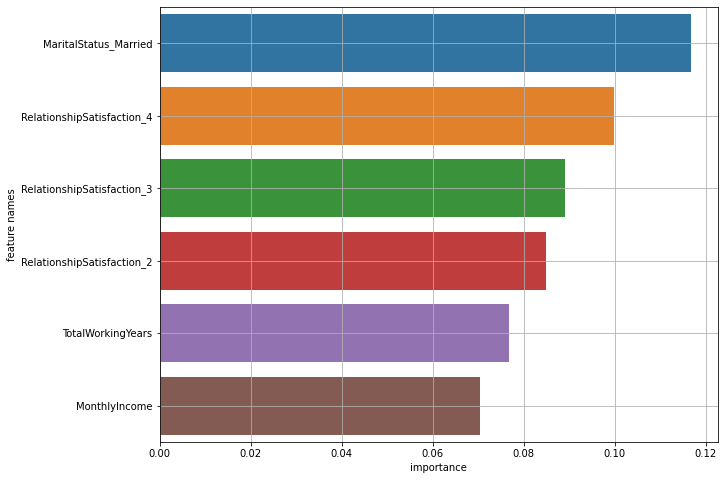

In [157]:
result = plot_feature_importance(model_gs.best_estimator_.feature_importances_, list(x), 6)

In [158]:
result

,feature_names,feature_importance
0,MaritalStatus_Married,0.116783
1,RelationshipSatisfaction_4,0.099860
2,RelationshipSatisfaction_3,0.088960
3,RelationshipSatisfaction_2,0.084913
4,TotalWorkingYears,0.076759
5,MonthlyIncome,0.070401


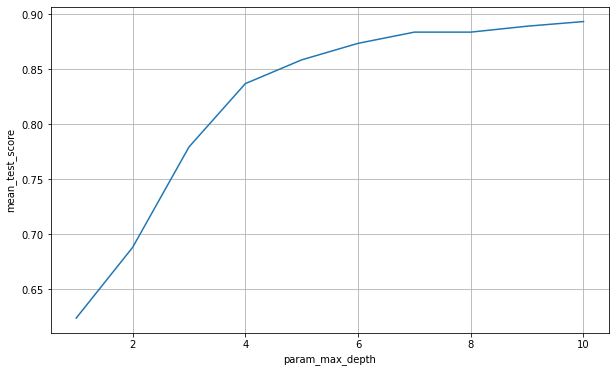

In [159]:
# 튜닝 과정 로그를 df로 저장 합시다.


# 튜닝 결과를 그래프로 그려봅시다.

result = pd.DataFrame(model_gs.cv_results_)

plt.figure(figsize = (10,6))
sns.lineplot(x='param_max_depth', y='mean_test_score', data = result)
plt.grid()
plt.show()

In [160]:
pred=model_gs.predict(x_val)

* rf

In [162]:
# 기본값으로 모델을 생성합니다.
rf=RandomForestClassifier()


In [163]:
rf.fit(x_train,y_train)

RandomForestClassifier()

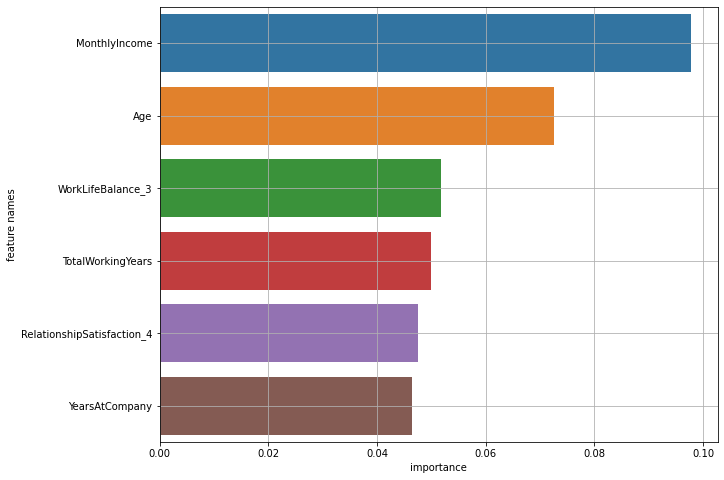

In [164]:
result = plot_feature_importance(rf.feature_importances_, list(x), 6)

* xgb

In [166]:
# 다음 범위로 그리드서치 튜닝을 진행합시다.
# max_depth : 1~6, learning_rate : 0.01 ~ 0.4, n_estimators : 50~150
params={'max_depth':range(1,7),'learning_rate':np.linspace(0.01,0.4,5),'n_estimators':range(50,150,10)}

In [167]:
xgb=XGBClassifier()
xgb_gs=GridSearchCV(xgb,params,cv=5,verbose=3)

In [168]:
xgb_gs.fit(x_train,y_train)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
[CV 1/5] END learning_rate=0.01, max_depth=1, n_estimators=50;, score=0.632 total time=   0.1s
[CV 2/5] END learning_rate=0.01, max_depth=1, n_estimators=50;, score=0.757 total time=   0.1s
[CV 3/5] END learning_rate=0.01, max_depth=1, n_estimators=50;, score=0.757 total time=   0.1s
[CV 4/5] END learning_rate=0.01, max_depth=1, n_estimators=50;, score=0.769 total time=   0.1s
[CV 5/5] END learning_rate=0.01, max_depth=1, n_estimators=50;, score=0.769 total time=   0.1s
[CV 1/5] END learning_rate=0.01, max_depth=1, n_estimators=60;, score=0.662 total time=   0.1s
[CV 2/5] END learning_rate=0.01, max_depth=1, n_estimators=60;, score=0.763 total time=   0.1s
[CV 3/5] END learning_rate=0.01, max_depth=1, n_estimators=60;, score=0.796 total time=   0.1s
[CV 4/5] END learning_rate=0.01, max_depth=1, n_estimators=60;, score=0.778 total time=   0.1s
[CV 5/5] END learning_rate=0.01, max_depth=1, n_estimators=60;, score=0.781 total

GridSearchCV(cv=5, estimator=XGBClassifier(),
             param_grid={'learning_rate': array([0.01  , 0.1075, 0.205 , 0.3025, 0.4   ]),
                         'max_depth': range(1, 7),
                         'n_estimators': range(50, 150, 10)},
             verbose=3)

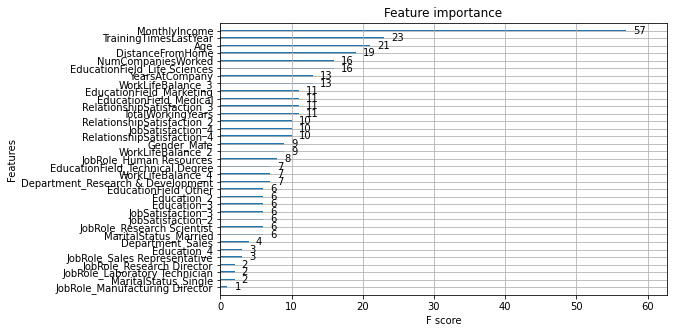

In [169]:
# importance_type='weight'
plot_importance(xgb_gs.best_estimator_)
plt.show()

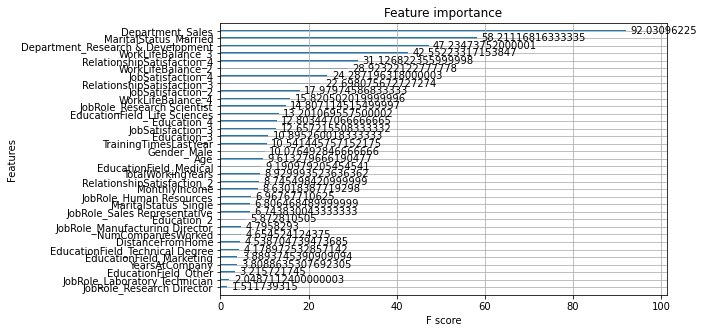

In [170]:

plot_importance(xgb_gs.best_estimator_,importance_type='gain')
plt.show()

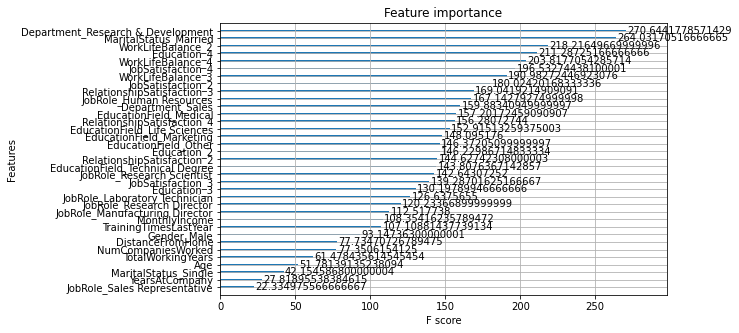

In [171]:
plot_importance(xgb_gs.best_estimator_,importance_type='cover')
plt.show()

* 모델 성능 비교
    * 세 모델 중 성능이 가장 좋은 모델은?

In [172]:
pred1=model_gs.predict(x_val)
pred2=rf.predict(x_val)
pred3=xgb_gs.predict(x_val)

In [173]:
print(classification_report(y_val,pred1))

              precision    recall  f1-score   support

           0       0.94      0.86      0.90       217
           1       0.06      0.15      0.09        13

    accuracy                           0.82       230
   macro avg       0.50      0.51      0.49       230
weighted avg       0.89      0.82      0.85       230



In [174]:
print(classification_report(y_val,pred2))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       217
           1       0.50      0.38      0.43        13

    accuracy                           0.94       230
   macro avg       0.73      0.68      0.70       230
weighted avg       0.94      0.94      0.94       230



In [175]:
print(classification_report(y_val,pred3))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       217
           1       0.27      0.23      0.25        13

    accuracy                           0.92       230
   macro avg       0.61      0.60      0.60       230
weighted avg       0.92      0.92      0.92       230



* 변수 중요도 비교 : 세 모델간 변수 중요도를 비교해 봅시다. 

가장 좋은 모델 찾고 -> 변수 중요도 확인

* 변수 중요도의 차이를 통해 무엇을 파악할 수 있나요?

______
